In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("../data/train.csv")
df.head()

,review,sentiment
0,I caught this little gem totally by accident b...,positive
1,I can't believe that I let myself into this mo...,negative
2,*spoiler alert!* it just gets to me the nerve ...,negative
3,If there's one thing I've learnt from watching...,negative
4,"I remember when this was in theaters, reviews ...",negative


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     40000 non-null  object
 1   sentiment  40000 non-null  object
dtypes: object(2)
memory usage: 625.1+ KB


In [5]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

The dataset contains no missing values.
All samples include text reviews and sentiment labels.

In [7]:
df["sentiment"].value_counts()

sentiment
positive    20000
negative    20000
Name: count, dtype: int64

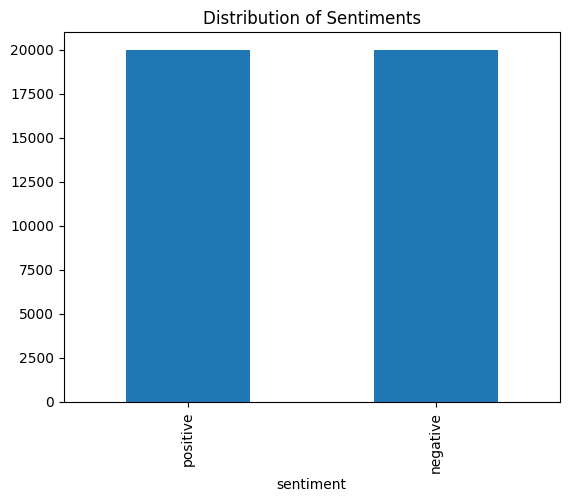

In [6]:
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Distribution of Sentiments")
plt.show()

The dataset is well balanced between positive and negative reviews, which reduces the risk of bias during training.

In [15]:
(df["review"].str.strip() == "").sum()

np.int64(0)

The dataset does not contain empty reviews.

In [17]:
(df["review_length"] < 10).sum()


np.int64(4)

Only a small fraction of reviews are extremely short, which reduces noise in the dataset.

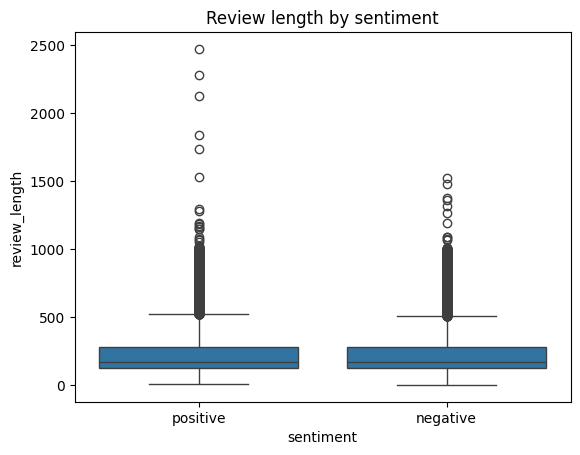

In [18]:
sns.boxplot(data=df, x="sentiment", y="review_length")
plt.title("Review length by sentiment")
plt.show()

The distribution of review lengths is similar for positive and negative sentiments.
This suggests that sentiment is not determined by the length of the review, but rather by the specific words used.

In [13]:
def count_words(text):
    words = text.split()
    return len(words)

df["review_length"] = df["review"].apply(count_words)

df["review_length"].describe()

count    40000.000000
mean       231.362750
std        171.083908
min          4.000000
25%        126.000000
50%        173.000000
75%        282.000000
max       2470.000000
Name: review_length, dtype: float64

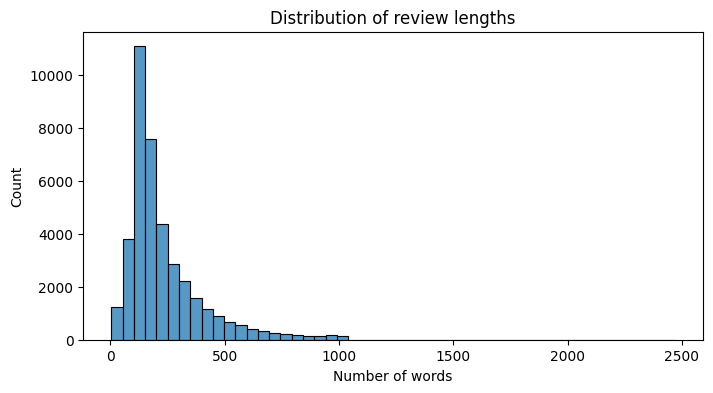

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(df["review_length"], bins=50)
plt.title("Distribution of review lengths")
plt.xlabel("Number of words")
plt.show()

Review lengths vary significantly, indicating the need for text normalization and robust vectorization methods.

In [10]:
from collections import Counter
import re

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        words.extend(re.findall(r"\b\w+\b", text.lower()))
    return Counter(words).most_common(n)

top_pos = get_top_words(df[df.sentiment == "pos"]["review"])
top_neg = get_top_words(df[df.sentiment == "neg"]["review"])

top_pos, top_neg

([], [])

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = ENGLISH_STOP_WORDS

df["stopword_count"] = df["review"].apply( lambda x: sum(w.lower() in stop_words for w in x.split()) )

df["word_count"] = df["review"].str.split().str.len()

df["stopword_ratio"] = df["stopword_count"] / df["word_count"]

df.groupby("sentiment")["stopword_ratio"].mean()

sentiment
negative    0.491544
positive    0.491536
Name: stopword_ratio, dtype: float64

The proportion of stopwords is similar across positive and negative reviews, indicating that stopwords alone are not discriminative for sentiment classification.